# Laboratorio de repaso de Python e introducción a POO

**Desarrollo de Sistemas de Inteligencia Artificial**

## Objetivos

Al finalizar el laboratorio se espera que puedan:

- utilizar condicionales considerando los valores *truthy* y *falsy*;
- construir repeticiones con `for`, `while` y `range()`;
- desempaquetar secuencias y valores retornados por funciones;
- definir funciones que retornen uno o varios resultados y reconocer funciones `lambda`;
- reconocer las formas habituales de importar módulos;
- crear y operar vectores y matrices con NumPy;
- explorar y visualizar datos con Pandas y Matplotlib;
- reconocer clases, objetos, constructores, atributos y métodos.

> Este laboratorio recupera contenidos previos. La programación orientada a objetos se introduce solamente en su nivel fundamental; otros conceptos se incorporarán cuando resulten necesarios durante la cursada.

# 1. Condicionales y valores *truthy* y *falsy*

Una condición permite decidir qué instrucciones deben ejecutarse. Python no exige que toda condición produzca explícitamente `True` o `False`: también puede interpretar la **veracidad** de un valor.

Los valores considerados falsos se denominan *falsy*. Entre los más habituales se encuentran:

- `False`;
- `None`;
- los números iguales a cero: `0`, `0.0`;
- las cadenas vacías: `""`;
- las colecciones vacías: `[]`, `{}`, `()`, `set()`.

En general, los demás valores son *truthy*.

In [25]:
# Una lista es una secuencia mutable que puede reunir valores de distintos tipos.
valores = [False, None, 0, 0.0, "", [], {}, (), "0", "False", -5, [0]]

for valor in valores:
    # repr obtiene la representación del valor y bool convierte su veracidad a True o False.
    # Las llaves de {bool(valor)} crean un conjunto con un elemento, no un diccionario.
    print(repr(valor), '->', {bool(valor)})




False -> {False}
None -> {False}
0 -> {False}
0.0 -> {False}
'' -> {False}
[] -> {False}
{} -> {False}
() -> {False}
'0' -> {True}
'False' -> {True}
-5 -> {True}
[0] -> {True}


### Ejemplo completo de validación

`not nombre` resulta verdadero cuando `nombre` contiene una cadena vacía. Esto permite escribir validaciones breves, siempre que todos los valores *falsy* representen la misma situación para el problema.

In [26]:
# Las comillas delimitan cadenas de texto; edad_texto todavía no contiene un número.
nombre = "Marta"

edad_texto = "35"

if not nombre:
    mensaje = "Debe ingresar un nombre"

elif not edad_texto:
    mensaje = "Debe ingresar una edad"

# isdigit comprueba que el texto contenga solo dígitos. No admite signos ni decimales;
# algunos dígitos Unicode tampoco se pueden convertir con int.
elif not edad_texto.isdigit():
    mensaje = "La edad debe ser un numero entero"

else:
    # int convierte el texto numérico a un entero.
    edad = int(edad_texto)

    if edad >= 18:
        # Una f-string incorpora los valores de las expresiones escritas entre llaves.
        mensaje = f"{nombre} es mayor de edad."

    else:
        mensaje = f"{nombre} es menor de edad."

print(mensaje)

Marta es mayor de edad.


### `None` no siempre significa lo mismo que cero

El uso de `if not valor` no es apropiado cuando el programa debe diferenciar entre ausencia de información y un cero válido. En esos casos debe compararse explícitamente con `None` mediante `is None`.

In [27]:
# La cadena "0" es truthy porque no está vacía; el entero 0 es falsy.
# not invierte la veracidad; is None distingue la ausencia de valor de un cero válido.
cantidad = '0'

if cantidad:
    print("Se ingreso una cantidad")

cantidad = 0

if not cantidad:
    print("Parece que no se ingreso otra cantidad")

if cantidad is None:
    print("Efectivamente la cantidad no fue ingresada")

else:
    print(f"La cantidad ingresada es {cantidad}")

Se ingreso una cantidad
Parece que no se ingreso otra cantidad
La cantidad ingresada es 0


### Ejercicio 1 — Resuelto

Dado un valor que representa una lista de observaciones, informar si existen datos para procesar. Si existen, mostrar cuántas observaciones contiene.

In [28]:
# len(observaciones) obtiene la cantidad de elementos de la lista.
observaciones = [18, 21, 25, 19]

if observaciones:
    print(f"Se procesaran {len(observaciones)} observaciones")

else:
    print("No existen observaciones para procesar")

Se procesaran 4 observaciones


# 2. Bucles y `range()`

- `for` se utiliza principalmente para recorrer los elementos de un iterable.
- `while` repite un bloque mientras una condición sea verdadera.
- `range(inicio, fin, paso)` genera una secuencia de enteros. El valor indicado como `fin` **no se incluye**.

In [29]:
# range(fin) produce enteros desde 0 y excluye fin. Con tres argumentos se indican
# inicio, fin y paso: range(2, 8, 2) produce 2, 4, 6; range(5, 0, -1), 5, 4, 3, 2, 1.
print("range(5):")

for numero in range(5):
    print(numero, end=" ")

print("\n\nrange(2, 8, 2):")

for numero in range(2, 8, 2):

    print(numero, end=" ")


print("\n\nrange(5, 0, -1):")

for numero in range(5, 0, -1):

    print(numero, end=" ")

range(5):
0 1 2 3 4 

range(2, 8, 2):
2 4 6 

range(5, 0, -1):
5 4 3 2 1 

### Recorrido por índices y uso de `enumerate()`

`range(len(...))` permite recorrer índices. Sin embargo, si se necesitan simultáneamente el índice y el elemento, `enumerate()` suele expresar mejor la intención.

In [30]:
# Los corchetes acceden a una posición de la secuencia; los índices empiezan en 0.
# enumerate produce pares (contador, elemento). start=1 cambia el contador, no los índices.
nombres = ["Ana", "Bruno", "Carla"]

for indice in range(len(nombres)):

    print(indice, nombres[indice])

print()

for indice, nombre in enumerate(nombres, start=1):
    print(f"{indice}. {nombre}")

0 Ana
1 Bruno
2 Carla

1. Ana
2. Bruno
3. Carla


In [ ]:

clave_correcta = "python"

intentos = ["java", "javascript", "typescript", "python", "c#"]

# posicion guarda el índice del siguiente intento y clave, la última entrada leída.
posicion = 0

clave = ""


# while repite mientras su condición sea verdadera. and exige que ambas comparaciones
# se cumplan; el límite de posicion evita acceder fuera de la lista.
while clave != clave_correcta and posicion < len(intentos):

    clave = intentos[posicion]

    print(f"Intento { posicion + 1}: {clave}")

    # += 1 incrementa el contador y permite avanzar hacia el final de los intentos.
    posicion += 1

if clave == clave_correcta:

    print("Acceso permitido")

else:
    print("Cantidad de intentos agotada")



# input devuelve lo escrito por la persona como una cadena de texto.
# El segundo ejemplo admite una entrada inicial y dos reintentos.
# != compara desigualdad, == compara igualdad y or acepta cualquiera de sus condiciones.
nombre = input("ingrese un nombre")
contador = 0
# Si el nombre ingresado no es marta, me vuelva a pedir que ingrese el nombre, hasta 3 veces

while nombre != "marta" and nombre != "Marta" and contador < 2:   # julian
    print("Nombre incorrecto")
    nombre = input("Ingrese otro nombre")
    contador = contador + 1

if nombre == "Marta" or nombre == "marta":
    print("El nombre es correcto!")
else:
    print("Adivinar no es lo tuyo")

Intento 1: java
Intento 2: javascript
Intento 3: typescript
Intento 4: python
Acceso permitido


### Ejercicio 2 — Resuelto

Mostrar la tabla de multiplicar del 7, desde `7 × 1` hasta `7 × 10`.

In [ ]:
numero = 7

for multiplicador in range(1,11):
    resultado = numero * multiplicador
    print(f"{numero} x {multiplicador} = {resultado}")

7 x 1 = 7
7 x 2 = 14
7 x 3 = 21
7 x 4 = 28
7 x 5 = 35
7 x 6 = 42
7 x 7 = 49
7 x 8 = 56
7 x 9 = 63
7 x 10 = 70


# 3. Desempaquetado y funciones

En Python, el **desempaquetado** permite asignar los elementos de una secuencia a distintas variables en una única instrucción.

In [ ]:
# Una tupla es una secuencia inmutable: no permite reemplazar sus elementos.
persona = ("Ana", 25, "Datos e IA")

# El desempaquetado asigna cada posición a una variable; las cantidades deben coincidir.
nombre, edad, area = persona

print(nombre)

print(edad)

print(area)


Ana
25
Datos e IA


In [ ]:
numeros = [10, 20, 30, 40, 50]


# El asterisco recoge los elementos sobrantes en una nueva lista llamada restantes.
# Esta operación no elimina elementos de numeros.
primero, segundo, *restantes = numeros

print(primero)
print(segundo)
print(restantes)

print(numeros)

# El ejemplo desactivado con pop(2) extraería y devolvería el tercer elemento de la lista.
# treinta =  numeros.pop(2)
# 
# print(treinta)
# 
# print(numeros)

10
20
[30, 40, 50]
[10, 20, 30, 40, 50]


### Funciones y `return`

Una función agrupa instrucciones que cumplen una tarea. Los parámetros reciben los datos de entrada y `return` entrega el resultado al código que llamó a la función.

Cuando los valores se separan mediante comas en `return`, Python construye y devuelve una **tupla**.

In [ ]:
# def define una función reutilizable; numeros es el parámetro que recibe los datos.
# Este cálculo requiere una secuencia numérica no vacía.
def calcular_estadisticas(numeros):
    # min y max obtienen el menor y el mayor valor.
    minimo = min(numeros)

    maximo = max(numeros)

    # sum suma los elementos; dividir por su cantidad obtiene la media aritmética.
    promedio = sum(numeros) / len(numeros)

    # return termina la función. Los valores separados por comas forman una tupla.
    return minimo, maximo, promedio 

# resultado = calcular_estadisticas([6,5,10,7])
calcular_estadisticas([6,5,10,7])
# print(resultado)
# print(type(resultado))

(5, 10, 7.0)

In [ ]:
# resultado recibe el promedio, que ocupa la tercera posición de la tupla retornada.
minimo, maximo, resultado = calcular_estadisticas([6,5,10,7])

print(minimo)
print(maximo)
print(resultado)

5
10
7.0


### Ejercicio 3 — Resuelto

Crear una función que reciba una lista de calificaciones y retorne la cantidad de aprobadas y desaprobadas. Se considera aprobada una calificación igual o superior a 6.

In [ ]:
# nota_minima=6 define un valor predeterminado que se usa cuando se omite ese argumento.
def contar_resultados(calificaciones, nota_minima=6):
    # Estos contadores son locales: se inicializan nuevamente en cada llamada.
    aprobadas = 0

    desaprobadas = 0

    for calificacion in calificaciones:

        if calificacion >= nota_minima:
            aprobadas += 1
        else:
            desaprobadas += 1

    return aprobadas, desaprobadas


aprobadas, desaprobadas = contar_resultados([8, 4, 7, 9, 3, 6])

print("Aprobadas:", aprobadas)
print("Desaprobadas:", desaprobadas)

Aprobadas: 4
Desaprobadas: 2


## Funciones `lambda`

Una función `lambda` es una función anónima y breve formada por una única expresión. Su sintaxis general es:

```python
lambda parametros: expresion
```

No se escribe `return`: el resultado de la expresión se retorna automáticamente. Resulta útil cuando otra función necesita recibir un comportamiento sencillo, por ejemplo mediante el parámetro `key` de `sorted()`.

> Una función `lambda` no reemplaza a todas las funciones definidas con `def`. Si la operación requiere varias instrucciones, validaciones, documentación o reutilización frecuente, debe utilizarse `def`.

In [ ]:
def calcular_cuadrado(numero):
    # ** es el operador de potencia: numero ** 2 calcula el cuadrado.
    return numero ** 2

cuadrado = calcular_cuadrado(5)

print(cuadrado)

# lambda crea una función de una única expresión cuyo resultado se devuelve automáticamente.
cuadrado_lambda = lambda numero: numero ** 2

print(cuadrado_lambda(5))
print(cuadrado_lambda(2))
print(cuadrado_lambda(8))


25
25
4
64


### Uso de `lambda` como argumento

En el siguiente ejemplo, `sorted()` recibe una función mediante `key`. Para cada tupla, la función `lambda` retorna el segundo elemento, que será utilizado como criterio de ordenamiento.

In [ ]:
estudiantes = [
    ("Ana", 8),
    ("Bruno", 6),
    ("Carla", 9)
]

# sorted crea una lista ordenada sin modificar la original. key recibe la función
# que extrae el criterio de ordenamiento; reverse=True solicita orden descendente.
estudiantes_ordendos = sorted(
    estudiantes,
    key = lambda cada_estudiante: cada_estudiante[1],
    reverse=True
)

print(estudiantes_ordendos)
print(estudiantes)



[('Carla', 9), ('Ana', 8), ('Bruno', 6)]
[('Ana', 8), ('Bruno', 6), ('Carla', 9)]


`sorted()` y `sort()` no son lo mismo

| Característica                  | `sorted()`                                                                        | `.sort()`                                        |
| ------------------------------- | --------------------------------------------------------------------------------- | ------------------------------------------------ |
| Tipo                            | Función incorporada de Python                                                     | Método de las listas                             |
| Forma de uso                    | `sorted(coleccion)`                                                               | `lista.sort()`                                   |
| Estructuras admitidas           | Cualquier iterable: listas, tuplas, conjuntos, diccionarios, etc.                 | Solamente listas                                 |
| Modifica la estructura original | No                                                                                | Sí                                               |
| Resultado                       | Devuelve una lista nueva ordenada                                                 | Devuelve `None`                                  |
| Conserva la colección original  | Sí                                                                                | No                                               |
| Orden descendente               | `sorted(coleccion, reverse=True)`                                                 | `lista.sort(reverse=True)`                       |
| Criterio personalizado          | `sorted(coleccion, key=funcion)`                                                  | `lista.sort(key=funcion)`                        |
| Uso recomendado                 | Cuando se necesita conservar la colección original o se trabaja con otro iterable | Cuando se desea modificar directamente una lista |


### `lambda` con `map()` y `filter()`

`map()` transforma cada elemento y `filter()` conserva los elementos que cumplen una condición. Ambos retornan iteradores, por eso se convierten en listas para visualizar sus resultados. En muchos casos, una comprensión de listas constituye una alternativa más legible.

In [ ]:
numeros = [1, 2, 3, 4, 5]

# map aplica una función a cada elemento y devuelve un iterador; list reúne sus resultados.
cuadrados = list(map(lambda numero: numero**2, numeros))
print(cuadrados)

# filter conserva los elementos que satisfacen la función. % calcula el resto:
# un resto igual a cero al dividir por 2 identifica números pares.
pares = list(filter(lambda numero: numero % 2 == 0, numeros))

print(pares)

[1, 4, 9, 16, 25]
[2, 4]


# 4. Importación de módulos

Las importaciones permiten utilizar código definido en módulos y bibliotecas.

```python
import modulo
from modulo import elemento
import modulo as alias
```

Los alias `np`, `pd` y `plt` son convenciones ampliamente utilizadas; no son palabras reservadas de Python.

In [ ]:
# math aporta funciones matemáticas, como sqrt para la raíz cuadrada.
import math

# from ... import incorpora mean directamente al espacio de nombres actual.
from statistics import mean

# as asigna un alias. np, pd y plt abrevian las bibliotecas de arrays, tablas y gráficos.
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

print("Raiz cuadrada:", math.sqrt(25))

print("Promedio:", mean([4, 6, 8]))

Raiz cuadrada: 5.0
Promedio: 6


| Concepto | Definición | Ejemplo | Forma de uso |
|---|---|---|---|
| Script | Archivo de Python pensado principalmente para ejecutarse directamente. | `programa.py` | `python programa.py` |
| Módulo | Archivo o componente importable que contiene variables, funciones o clases reutilizables. Un archivo `.py` puede funcionar como módulo. | `math`, `statistics`, `utilidades.py` | `import math` |
| Paquete | Estructura que agrupa módulos y, posiblemente, otros subpaquetes bajo un mismo nombre. Habitualmente corresponde a una carpeta. | `matplotlib`, `sklearn.model_selection` | `from sklearn import model_selection` |
| Biblioteca | Conjunto de funcionalidades reutilizables. Puede estar formada por uno o varios paquetes y módulos. Es un concepto más general que una estructura concreta de Python. | NumPy, Pandas, Matplotlib | `import pandas as pd` |
| Biblioteca estándar | Conjunto de módulos y paquetes incluidos con Python, por lo que no requieren una instalación adicional. | `math`, `statistics`, `pathlib`, `urllib` | `from pathlib import Path` |
| Biblioteca externa | Biblioteca desarrollada fuera de la distribución estándar de Python. Debe instalarse antes de importarse. | NumPy, Pandas, Matplotlib | `pip install pandas` |
| Framework | Conjunto estructurado de herramientas que define una forma de construir aplicaciones y suele controlar parte del flujo de ejecución. | Django, Flask, FastAPI | Depende del framework |

Un mismo recurso puede describirse en distintos niveles. Por ejemplo, Matplotlib es una biblioteca; dentro de ella existe el paquete matplotlib y dentro de este se encuentra el módulo pyplot.

Se recomienda evitar `from modulo import *`, porque incorpora numerosos nombres al espacio actual y dificulta identificar su origen.

## Listas de Python y arrays de NumPy

Antes de trabajar con NumPy conviene distinguir ambas estructuras. Aunque las dos almacenan varios valores y utilizan índices, no tienen el mismo propósito.

| Característica | Lista de Python | Array de NumPy |
|---|---|---|
| Creación | `[1, 2, 3]` | `np.array([1, 2, 3])` |
| Tipos de datos | Puede mezclar tipos libremente | Normalmente utiliza un único tipo común (`dtype`) |
| Operaciones matemáticas | Requiere recorridos o comprensiones | Permite operaciones vectorizadas |
| Dimensiones | Puede anidar listas, pero no posee `shape` | Gestiona dimensiones y forma mediante `ndim` y `shape` |
| Tamaño | Se amplía fácilmente con `append()` | Su tamaño es fijo; las modificaciones suelen crear otro array |
| Uso habitual | Colecciones generales | Cálculo numérico, matrices y ciencia de datos |

La diferencia se observa claramente al utilizar el operador `*`: en una lista repite sus elementos; en un array multiplica cada elemento.

In [ ]:
lista = [1, 2, 3]

# np.array crea un array numérico: * 2 multiplica cada elemento.
# En una lista de Python, la misma operación repite su contenido.
array = np.array([1, 2, 3])

print("Lista * 2", lista * 2)
print("Array * 2", array * 2)

Lista * 2 [1, 2, 3, 1, 2, 3]
Array * 2 [2 4 6]


# 5. NumPy: vectores y matrices

NumPy trabaja principalmente con objetos `ndarray`. Un array de una dimensión puede interpretarse como un vector y uno de dos dimensiones como una matriz.

> Aunque existe `np.matrix`, no se utilizará: para el trabajo habitual se prefieren arrays `ndarray` bidimensionales.

In [ ]:
# ndim cuenta ejes; shape es la tupla de tamaños por eje; size cuenta todos los elementos.
# len(vector) mide solo el primer eje, por lo que coincide con size en este vector.
# Las listas nativas no poseen los atributos ndim, shape ni size.
vector = np.array([8, 4, 7, 9, 6])

lista = [8, 4, 7, 9, 6]

print(vector)

print("Dimensiones:", vector.ndim)

print("Forma:", vector.shape)

print("Cantidad de elementos:", len(vector))
print("Cantidad de elementos:", vector.size)
print("Cantidad de elementos:", len(lista))
# print("Cantidad de elementos:", lista.size)



[8 4 7 9 6]
Dimensiones: 1
Forma: (5,)
Cantidad de elementos: 5
Cantidad de elementos: 5
Cantidad de elementos: 5


In [ ]:
# Las listas anidadas crean una matriz de cuatro estudiantes por tres evaluaciones.
# Su forma es (4, 3) y tiene dos dimensiones: filas y columnas.
calificaciones = np.array([
    [8, 7, 9],
    [6, 5, 7],
    [10, 9, 8],
    [4, 6, 5]
])

print(calificaciones)

print("Dimensiones:", calificaciones.ndim)

print("Forma:", calificaciones.shape )



[[ 8  7  9]
 [ 6  5  7]
 [10  9  8]
 [ 4  6  5]]
Dimensiones: 2
Forma: (4, 3)


### Acceso a elementos, filas y columnas

En una matriz se indican primero la fila y luego la columna. Los índices comienzan en cero.

In [ ]:
# Fila 1 y columna 1

print("Fila 1, columna 1:", calificaciones[0][0])
print("Fila 1, columna 1:", calificaciones[0, 0])

print("Fila 3, columna 2:", calificaciones[2, 1])

# En NumPy, [fila, columna] selecciona sobre ambos ejes. : toma todo el eje:
# [0, :] obtiene la primera fila y [:, 1], la segunda columna.
primera_fila = calificaciones[0, :]
segunda_columna = calificaciones[:, 1]

print("Primera fila", primera_fila)
print("Segunda fila", segunda_columna)

Fila 1, columna 1: 8
Fila 1, columna 1: 8
Fila 3, columna 2: 9
Primera fila [8 7 9]
Segunda fila [7 5 9 6]


### Operaciones por eje

- `axis=0` reduce las filas y produce un resultado por columna.
- `axis=1` reduce las columnas y produce un resultado por fila.

In [ ]:
# [[ 8  7  9]
#  [ 6  5  7]
#  [10  9  8]
#  [ 4  6  5]]

# mean() sin axis calcula la media global. axis=1 reduce las columnas y da un valor
# por fila; axis=0 reduce las filas y da un valor por columna.
promedio_general = calificaciones.mean()

print("Promedio general:", promedio_general)

promedio_por_estudiante = calificaciones.mean(axis=1)

print("Promedio por estudiante:", promedio_por_estudiante)

promedio_por_evaluacion = calificaciones.mean(axis=0)

print("Promedio por evaluacion:", promedio_por_evaluacion)

Promedio general: 7.0
Promedio por estudiante: [8. 6. 9. 5.]
Promedio por evaluacion: [7.   6.75 7.25]


### Comparaciones vectorizadas

Una comparación aplicada a un array genera otro array de valores booleanos. Para formular una única condición pueden emplearse `.any()` o `.all()`.

In [ ]:
# [[ 8  7  9]
#  [ 6  5  7]
#  [10  9  8]
#  [ 4  6  5]]

# La comparación vectorizada genera una máscara booleana con la misma forma del array.
# Su suma cuenta los True como 1 y los False como 0.
# any comprueba si hay algún True; all comprueba si todos lo son.
mascara_aprobadas = calificaciones >= 6

print(mascara_aprobadas)

print("Cantidad de notas aprobadas:", mascara_aprobadas.sum())

print("Existe algun 10?", (calificaciones == 10).any())

print("Todas las notas son aprobadas?", (calificaciones >= 6).all())

[[ True  True  True]
 [ True False  True]
 [ True  True  True]
 [False  True False]]
Cantidad de notas aprobadas: 9
Existe algun 10? True
Todas las notas son aprobadas? False


No debe escribirse `if calificaciones:` cuando el array contiene varios elementos. NumPy no puede decidir si se pretende comprobar todos los valores o al menos uno. Para comprobar si existen elementos puede utilizarse `calificaciones.size > 0`.

In [ ]:
if calificaciones.size > 0:
    print("La matriz contiene datos")

if(calificaciones == 10).any():
    print("Al menos una calificacion es igual a 10")

# El mensaje original menciona 10, pero la comparación de esta línea busca un 3.
if(calificaciones == 3).any():
    print("Al menos una calificacion es igual a 10")

La matriz contiene datos
Al menos una calificacion es igual a 10


### Ejercicio 4 — Resuelto

Obtener los promedios por estudiante e informar qué números de estudiante alcanzaron un promedio igual o superior a 6.

In [ ]:
# calificaciones = np.array([
#     [8, 7, 9],
#     [6, 5, 7],
#     [10, 9, 8],
#     [4, 6, 5]
# ])

promedios = calificaciones.mean(axis=1)
condicion_aprobados = promedios >= 6
# np.where(condicion) devuelve una tupla de arrays de índices, uno por eje.
# [0] extrae el único array de índices de esta máscara unidimensional.
indices_aprobados = np.where(condicion_aprobados)[0]
# Se suma 1 a los índices para presentar los números de estudiante desde 1.
numeros_estudiantes = indices_aprobados + 1

print("Promedios:", promedios)
print("condicion aprobados:", condicion_aprobados)
print("Indices aprobados:", indices_aprobados)
print("Estudiantes aprobados:", numeros_estudiantes)

Promedios: [8. 6. 9. 5.]
condicion aprobados: [ True  True  True False]
Indices aprobados: [0 1 2]
Estudiantes aprobados: [1 2 3]


# 6. Pandas y Matplotlib: dataset Titanic

Se utilizará la versión del dataset Titanic publicada en el repositorio de datos de Seaborn.

- [Descargar `titanic.csv`](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv)
- [Ver el archivo en GitHub](https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv)

La siguiente celda crea la carpeta `data` si no existe y descarga allí el archivo. Si `data/titanic.csv` ya existe, no vuelve a descargarlo.

## Corchetes y paréntesis en diccionarios y DataFrames

Los símbolos no son intercambiables: representan operaciones distintas.

| Escritura | Significado |
|---|---|
| `diccionario["clave"]` | Accede al valor asociado con una clave. Produce `KeyError` si la clave no existe. |
| `diccionario.get("clave")` | Llama al método `get()`. Permite obtener `None` o un valor predeterminado si la clave no existe. |
| `df["columna"]` | Selecciona una columna y devuelve una `Series`. |
| `df[["columna_1", "columna_2"]]` | Selecciona varias columnas y devuelve un `DataFrame`. |
| `df.loc[filas, columnas]` | Selecciona mediante etiquetas. `loc` es un indexador y por eso utiliza corchetes. |
| `df.iloc[filas, columnas]` | Selecciona mediante posiciones enteras. |
| `df.head()` | Llama al método `head`; los paréntesis ejecutan el método. |
| `df.groupby("pclass")` | Llama al método `groupby` y le pasa `"pclass"` como argumento. |

Por lo tanto, `df["age"].mean()` combina ambas operaciones: primero los corchetes seleccionan la columna `age` y después los paréntesis ejecutan su método `mean()`. Escribir `df("age")` sería incorrecto porque un DataFrame no es una función.

In [ ]:
# Un diccionario almacena pares clave-valor. [clave] obtiene el valor y falla si no existe;
# get permite devolver un valor predeterminado cuando falta la clave.
persona = {"nombre": "Ana", "edad": 25}


print(persona["nombre"])

print(persona.get("area", "Sin area informada"))

# DataFrame construye una tabla: cada clave del diccionario nombra una columna
# y cada lista contiene sus valores, con la misma longitud que las demás.
df_ejemplo = pd.DataFrame({
    "nombre": ["ana", "bruno"],
    "edad": [25, 31]
})

print(df_ejemplo)

# Seleccionar una columna por su nombre devuelve una Series de Pandas.
# Su método mean ignora los valores nulos al calcular la media.
edades = df_ejemplo["edad"]
print()

print(edades)

promedio_edades = edades.mean()

print()

print(promedio_edades)

Ana
Sin area informada
  nombre  edad
0    ana    25
1  bruno    31

0    25
1    31
Name: edad, dtype: int64

28.0


In [ ]:
# Path representa rutas con objetos; la ruta usada aquí es relativa al directorio del kernel.
from pathlib import Path
# urlretrieve descarga un recurso desde una URL y lo guarda en el archivo indicado.
from urllib.request import urlretrieve

# Las mayúsculas indican por convención que la URL se trata como una constante.
URL_TITANIC = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
ruta_titanic = Path("data/titanic.csv")

# Crea la carpeta `data`; también crea carpetas intermedias y no falla si ya existe.
ruta_titanic.parent.mkdir(parents=True, exist_ok=True)

if not ruta_titanic.exists():
    urlretrieve(URL_TITANIC, ruta_titanic)
    print(f"Archivo descargado en: {ruta_titanic}")
else:
    print(f"El archivo ya existe en: {ruta_titanic}")

Archivo descargado en: data\titanic.csv


### Carga e inspección inicial

La versión utilizada contiene nombres de columnas en minúsculas, como `survived`, `pclass`, `sex`, `age` y `fare`.

In [ ]:
# read_csv carga el archivo como DataFrame. head() devuelve las primeras cinco filas;
# display las presenta como tabla en Jupyter. shape indica (filas, columnas).
df = pd.read_csv(ruta_titanic)

# print(df)

display(df.head())

print("Filas y columnas:", df.shape)

NameError: name 'ruta_titanic' is not defined

In [ ]:
# info resume las columnas, sus tipos de datos y la cantidad de valores no nulos.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [ ]:
# Seleccionar con una lista de nombres conserva un DataFrame con esas columnas.
# describe resume las columnas numéricas; include="all" añade estadísticas
# de columnas no numéricas, como la cantidad de valores únicos y el más frecuente.
columnas_interes = ["survived", "pclass", "sex","age","fare", "embark_town"]

display(df[columnas_interes])
display(df[columnas_interes].describe())
display(df[columnas_interes].describe(include="all"))

,survived,pclass,sex,age,fare,embark_town
0,0,3,male,22.0,7.2500,Southampton
1,1,1,female,38.0,71.2833,Cherbourg
2,1,3,female,26.0,7.9250,Southampton
3,1,1,female,35.0,53.1000,Southampton
4,0,3,male,35.0,8.0500,Southampton
...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,Southampton
887,1,1,female,19.0,30.0000,Southampton
888,0,3,female,NaN,23.4500,Southampton
889,1,1,male,26.0,30.0000,Cherbourg


,survived,pclass,age,fare
count,891.000000,891.000000,714.000000,891.000000
mean,0.383838,2.308642,29.699118,32.204208
std,0.486592,0.836071,14.526497,49.693429
min,0.000000,1.000000,0.420000,0.000000
25%,0.000000,2.000000,20.125000,7.910400
50%,0.000000,3.000000,28.000000,14.454200
75%,1.000000,3.000000,38.000000,31.000000
max,1.000000,3.000000,80.000000,512.329200


,survived,pclass,sex,age,fare,embark_town
count,891.000000,891.000000,891,714.000000,891.000000,889
unique,NaN,NaN,2,NaN,NaN,3
top,NaN,NaN,male,NaN,NaN,Southampton
freq,NaN,NaN,577,NaN,NaN,644
mean,0.383838,2.308642,NaN,29.699118,32.204208,NaN
std,0.486592,0.836071,NaN,14.526497,49.693429,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,NaN
25%,0.000000,2.000000,NaN,20.125000,7.910400,NaN
50%,0.000000,3.000000,NaN,28.000000,14.454200,NaN
75%,1.000000,3.000000,NaN,38.000000,31.000000,NaN


### Supervivencia general

Como `survived` utiliza `0` para indicar que la persona no sobrevivió y `1` para indicar que sí sobrevivió, su promedio representa la proporción de supervivencia.

In [ ]:
# La media de una columna de ceros y unos equivale a la proporción de unos.
# El formato :.2% expresa el resultado como porcentaje con dos decimales.
proporcion_supervivencia = df["survived"].mean()

print("Proporcion de supervivencia:", proporcion_supervivencia)

print(f"Propocion supervivencia con amor: {proporcion_supervivencia:.2%}") 

Proporcion de supervivencia: 0.3838383838383838
Propocion supervivencia con amor: 38.38%


### Agrupamiento por clase

`groupby()` agrupa las filas según una variable. Luego se calcula el promedio de `survived` dentro de cada grupo.

In [ ]:
# Los paréntesis permiten extender la expresión a varias líneas.
# groupby reúne las filas por clase; luego se calcula la media de survived de cada grupo.
supervivencia_por_clase = (
    df.groupby("pclass")["survived"].mean()
)

display(supervivencia_por_clase)

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

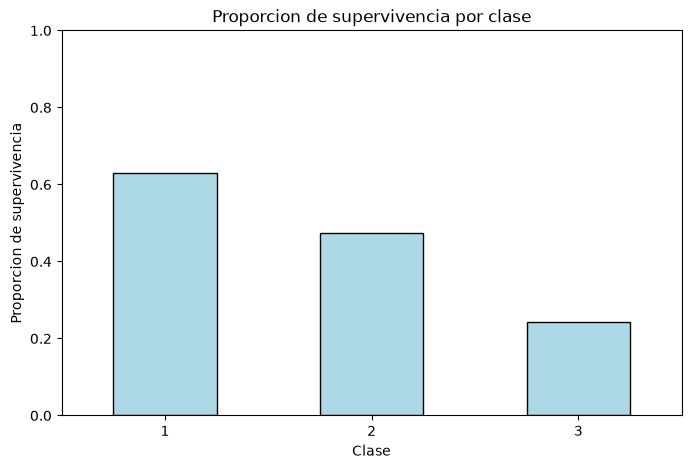

In [ ]:
# plot crea el gráfico y devuelve un objeto Axes para configurarlo. kind="bar" elige barras;
# color y edgecolor definen relleno y borde; figsize indica ancho y alto en pulgadas.
grafico = supervivencia_por_clase.plot(
    kind= "bar",
    color = "lightblue",
    edgecolor= "black",
    figsize=(8,5)
)

# Los métodos set_title, set_xlabel y set_ylabel definen el título y los nombres de los ejes.
# set_ylim fija los límites verticales y tick_params configura las etiquetas de las marcas.
grafico.set_title("Proporcion de supervivencia por clase")
grafico.set_xlabel("Clase")
grafico.set_ylabel("Proporcion de supervivencia")
grafico.set_ylim(0,1)
grafico.tick_params(axis="x", rotation=0)


# show presenta la figura terminada.
plt.show()

### Ejercicio 5 — Resuelto

Calcular y representar la proporción de supervivencia según sexo.

sex
male      0.188908
female    0.742038
Name: survived, dtype: float64

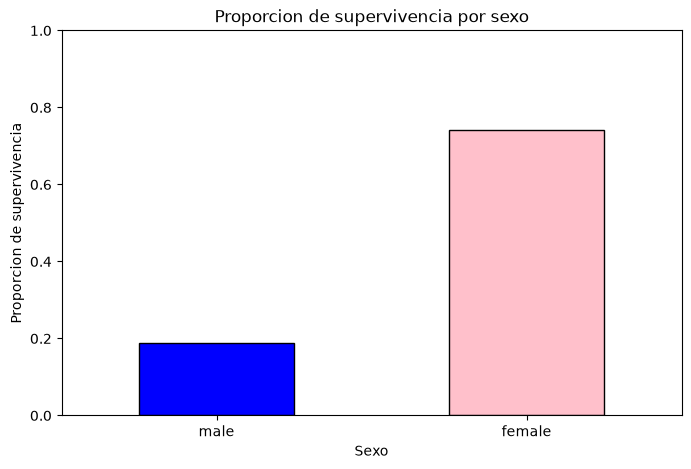

In [ ]:
supervivncia_por_sexo = (
    df.groupby("sex")["survived"]
    .mean()
    # sort_values ordena la Series por sus valores, de menor a mayor de forma predeterminada.
    .sort_values()
)

display(supervivncia_por_sexo)

graf = supervivncia_por_sexo.plot(
    kind="bar",
    color = ["blue", "pink"],
    edgecolor="black",
    figsize=(8,5)
)

graf.set_title("Proporcion de supervivencia por sexo")
graf.set_xlabel("Sexo")
graf.set_ylabel("Proporcion de supervivencia")
graf.set_ylim(0,1)
graf.tick_params(axis="x", rotation=0)

plt.show()

### Ejercicio 6 — Resuelto

Crear grupos etarios y comparar la proporción de supervivencia. Las edades ausentes permanecen como valores nulos y no se incluyen en los grupos.

## Práctica adicional con Titanic

Resolver los ejercicios 7 al 16 con el DataFrame `df` cargado desde `data/titanic.csv` y las bibliotecas ya importadas (`pd`, `np` y `plt`). Cada ejercicio incluye una celda para desarrollar la solución. Cuando se agreguen columnas o completen datos, trabajar sobre una copia para conservar el dataset original.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('data/titanic.csv')

### Ejercicio 7 — Selección y filtros combinados

1. Seleccionar las personas de tercera clase (`pclass == 3`) con edad conocida menor a 18 años.
2. Mostrar solamente `sex`, `age`, `fare` y `survived`, ordenadas por edad de menor a mayor.
3. Informar cuántas personas cumplen las condiciones y qué porcentaje representan sobre el total del dataset.

**Pista:** combinar condiciones con `&` y encerrar cada condición entre paréntesis; usar `.loc` y `.sort_values()`.

In [ ]:
filtro=(df['pclass'] == 3)&(df['age'] < 18)

columnas=['sex', 'age', 'fare', 'survived']

resultado=df.loc[filtro, columnas].sort_values('age')

cantidad=len(resultado)

porcentaje=cantidad/len(df)*100

print(resultado)

print(f"Cantidad: {cantidad}")

print(f"Porcentaje: {porcentaje:.2f}%")



        sex    age     fare  survived
803    male   0.42   8.5167         1
644  female   0.75  19.2583         1
469  female   0.75  19.2583         1
172  female   1.00  11.1333         1
381  female   1.00  15.7417         1
..      ...    ...      ...       ...
532    male  17.00   7.2292         0
500    male  17.00   8.6625         0
433    male  17.00   7.1250         0
114  female  17.00  14.4583         0
844    male  17.00   8.6625         0

[78 rows x 4 columns]
Cantidad: 78
Porcentaje: 8.75%


### Ejercicio 8 — Diagnóstico de valores faltantes

1. Crear una tabla con la cantidad y el porcentaje de valores nulos de cada columna.
2. Mostrar únicamente las columnas con datos faltantes, ordenadas de mayor a menor porcentaje.
3. Crear una copia de `df` y completar las edades ausentes con la mediana de `age`.
4. Comparar el promedio de edad antes y después de completar los datos. Explicar por qué podría cambiar.

**Pista:** usar `.isna()`, `.sum()`, `.copy()` y `.fillna()`. Conservar `df` sin modificar para los demás ejercicios.

In [ ]:
nulos = df.isna().sum()
porcentaje_nulos = df.isna().sum() / len(df) * 100
tabla_nulos = pd.DataFrame({
    'cantidad': nulos,
    'porcentaje': porcentaje_nulos
})
tabla_faltantes = tabla_nulos[tabla_nulos['cantidad'] > 0].sort_values('porcentaje', ascending=False)
df_copia = df.copy()

mediana_age = df['age'].median()
df_copia['age'] = df_copia['age'].fillna(mediana_age)

promedio_antes = df['age'].mean()
promedio_despues = df_copia['age'].mean()

print(f"Promedio antes: {promedio_antes:.2f}")
print(f"Promedio después: {promedio_despues:.2f}")
print (tabla_faltantes)

Promedio antes: 29.70
Promedio después: 29.36
             cantidad  porcentaje
deck              688   77.216611
age               177   19.865320
embarked            2    0.224467
embark_town         2    0.224467


### Ejercicio 9 — Tarifas y pasajeros destacados

1. Calcular el mínimo, el máximo, la media y la mediana de `fare`.
2. Mostrar las 10 filas con las tarifas más altas, incluyendo `pclass`, `sex`, `age`, `fare` y `embark_town`.
3. Contar cuántas personas tienen tarifa igual a cero.
4. Comparar la media con la mediana y explicar qué efecto podrían tener las tarifas muy altas.

**Pista:** usar `.describe()`, `.median()` y `.sort_values()` o `.nlargest()`.

In [ ]:
minimo = df['fare'].min()
maximo = df['fare'].max()
media = df['fare'].mean()
mediana = df['fare'].median()
 
print(f"Mínimo: {minimo:.2f}")
print(f"Máximo: {maximo:.2f}")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
 
top_10_tarifas = df.nlargest(10, 'fare')[['pclass', 'sex', 'age', 'fare', 'embark_town']]
print(top_10_tarifas)
 
tarifa_cero = (df['fare'] == 0).sum()
print(f"Pasajeros con tarifa 0: {tarifa_cero}")



Mínimo: 0.00
Máximo: 512.33
Media: 32.20
Mediana: 14.45
     pclass     sex   age      fare  embark_town
258       1  female  35.0  512.3292    Cherbourg
679       1    male  36.0  512.3292    Cherbourg
737       1    male  35.0  512.3292    Cherbourg
27        1    male  19.0  263.0000  Southampton
88        1  female  23.0  263.0000  Southampton
341       1  female  24.0  263.0000  Southampton
438       1    male  64.0  263.0000  Southampton
311       1  female  18.0  262.3750    Cherbourg
742       1  female  21.0  262.3750    Cherbourg
118       1    male  24.0  247.5208    Cherbourg
Pasajeros con tarifa 0: 15


### Ejercicio 10 — Supervivencia por clase y sexo

1. Agrupar simultáneamente por `pclass` y `sex`.
2. Para cada grupo, calcular la cantidad de pasajeros, la cantidad de sobrevivientes y el porcentaje de supervivencia.
3. Ordenar los grupos por porcentaje de supervivencia e identificar el mayor y el menor.
4. Escribir una conclusión breve que tenga en cuenta también el tamaño de cada grupo.

**Pista:** usar `groupby()` con una lista de columnas y `.agg()`. En `survived`, la suma cuenta sobrevivientes y la media multiplicada por 100 expresa el porcentaje.

In [ ]:
resumen_clase_sexo = df.groupby(['pclass', 'sex']).agg(
    cantidad=('survived', 'size'),
    sobrevivientes=('survived', 'sum'),
    porcentaje_supervivencia=('survived', lambda x: x.mean() * 100)
).sort_values('porcentaje_supervivencia', ascending=False)
 
print(resumen_clase_sexo)


               cantidad  sobrevivientes  porcentaje_supervivencia
pclass sex                                                       
1      female        94              91                 96.808511
2      female        76              70                 92.105263
3      female       144              72                 50.000000
1      male         122              45                 36.885246
2      male         108              17                 15.740741
3      male         347              47                 13.544669


### Ejercicio 11 — Familiares a bordo

1. Crear una copia llamada `df_familias` y agregar `tamano_familia = sibsp + parch + 1`.
2. Agregar `viaja_solo`, que sea verdadero cuando el tamaño familiar sea 1.
3. Comparar `viaja_solo` con la columna `alone` e informar la cantidad de diferencias.
4. Calcular la cantidad de pasajeros y el porcentaje de supervivencia según viajen solos o acompañados.

` sibsp ` indica hermanos/as y cónyuges a bordo; `parch`, padres/madres e hijos/as. El 1 incluye al propio pasajero.

In [ ]:
df_familias = df.copy()
df_familias['tamano_familia'] = df_familias['sibsp'] + df_familias['parch'] + 1
df_familias['viaja_solo'] = df_familias['tamano_familia'] == 1
 
diferencias = (df_familias['viaja_solo'] != df_familias['alone']).sum()
print(f"Diferencias con 'alone': {diferencias}")
 
resumen_solos = df_familias.groupby('viaja_solo').agg(
    cantidad=('survived', 'size'),
    porcentaje_supervivencia=('survived', lambda x: x.mean() * 100)
)
print(resumen_solos)


Diferencias con 'alone': 0
            cantidad  porcentaje_supervivencia
viaja_solo                                    
False            354                 50.564972
True             537                 30.353818


### Ejercicio 12 — Función de resumen reutilizable

1. Definir `resumir_pasajeros(datos)` para recibir un DataFrame y devolver una tupla con la cantidad de pasajeros, la edad promedio y la proporción de supervivencia.
2. Si el DataFrame está vacío, devolver `(0, None, None)`. Para la edad promedio, ignorar edades ausentes; si no hay ninguna edad conocida, devolver `None` en esa posición.
3. Aplicar la función al dataset completo y luego a cada clase usando un `for`.
4. Desempaquetar los resultados y mostrarlos con etiquetas claras; expresar la supervivencia como porcentaje.
5. Probar también con `df.iloc[0:0]`.

**Pista:** usar `.empty` para comprobar si un DataFrame está vacío y `.notna().any()` para detectar si existen edades conocidas.

In [ ]:
def resumir_pasajeros(datos):
    if datos.empty:
        return {'cantidad': 0, 'edad_promedio': None, 'supervivencia': None}

    cantidad = len(datos)
    edad_promedio = datos['age'].mean() if datos['age'].notna().any() else None
    proporcion_supervivencia = datos['survived'].mean()
    return {'cantidad': cantidad, 'edad_promedio': edad_promedio, 'supervivencia': proporcion_supervivencia}
def mostrar(titulo, resumen):
    print(titulo)
    print("  Cantidad:", resumen['cantidad'])
    if resumen['cantidad'] == 0:
        print("  Sin datos")
    else:
        print("  Edad promedio:", round(resumen['edad_promedio'], 1))
        print("  Supervivencia:", round(resumen['supervivencia'] * 100, 1), "%")
    print()

mostrar("Todos", resumir_pasajeros(df))

for clase in [1, 2, 3]:
    mostrar("Clase " + str(clase), resumir_pasajeros(df[df['pclass'] == clase]))

mostrar("DataFrame vacío", resumir_pasajeros(df.iloc[0:0]))

Todos
  Cantidad: 891
  Edad promedio: 29.7
  Supervivencia: 38.4 %

Clase 1
  Cantidad: 216
  Edad promedio: 38.2
  Supervivencia: 63.0 %

Clase 2
  Cantidad: 184
  Edad promedio: 29.9
  Supervivencia: 47.3 %

Clase 3
  Cantidad: 491
  Edad promedio: 25.1
  Supervivencia: 24.2 %

DataFrame vacío
  Cantidad: 0
  Sin datos



### Ejercicio 13 — Clasificación de tarifas con una función

1. Definir `clasificar_tarifa(fare)` con estas categorías: `sin dato` si es nula, `gratuita` si vale 0, `económica` si es mayor a 0 y menor a 15, `media` si es mayor o igual a 15 y menor a 50, y `alta` si es mayor o igual a 50.
2. Aplicar la función a `fare` y guardar el resultado en una columna `categoria_tarifa` de una copia de `df`.
3. Contar los pasajeros de cada categoría y calcular su porcentaje de supervivencia.
4. Ordenar los resultados por cantidad de pasajeros usando una función `lambda` como `key` de `sorted()` sobre una lista de tuplas `(categoria, cantidad)`.

**Pista:** usar `pd.isna()`, condicionales, `.apply()` y `.value_counts()`.

In [ ]:
def clasificar_tarifa(fare):
    if pd.isna(fare):
        return "sin dato"
    elif fare == 0:
        return "gratuita"
    elif fare < 15:
        return "económica"
    elif fare < 50:
        return "media"
    else:
        return "alta"
 
df_tarifas = df.copy()
df_tarifas['categoria_tarifa'] = df_tarifas['fare'].apply(clasificar_tarifa)
 
resumen_categorias = df_tarifas.groupby('categoria_tarifa').agg(
    cantidad=('survived', 'size'),
    porcentaje_supervivencia=('survived', lambda x: x.mean() * 100)
)
print(resumen_categorias)
 
lista_categorias = list(zip(resumen_categorias.index, resumen_categorias['cantidad']))
lista_ordenada = sorted(lista_categorias, key=lambda x: x[1], reverse=True)
print(lista_ordenada)


                  cantidad  porcentaje_supervivencia
categoria_tarifa                                    
alta                   161                 67.701863
económica              442                 25.565611
gratuita                15                  6.666667
media                  273                 43.589744
[('económica', 442), ('media', 273), ('alta', 161), ('gratuita', 15)]


### Ejercicio 14 — Edades con NumPy

1. Convertir las edades conocidas en un array de NumPy, excluyendo los valores nulos.
2. Calcular la edad mínima, máxima, promedio y los percentiles 25, 50 y 75.
3. Usar una máscara booleana para obtener las edades entre 18 y 60 años, ambos incluidos.
4. Informar cuántas cumplen esa condición y qué porcentaje representan sobre las personas con edad conocida.
5. Verificar que el promedio obtenido coincide con `df["age"].mean()` usando `np.isclose()`.

**Pista:** usar `.dropna().to_numpy()`, `np.percentile()` y operaciones vectorizadas.

In [ ]:
edades = df['age'].dropna().to_numpy()
 
edad_min = edades.min()
edad_max = edades.max()
edad_promedio = edades.mean()
p25, p50, p75 = np.percentile(edades, [25, 50, 75])
 
print(f"Mínima: {edad_min}, Máxima: {edad_max}, Promedio: {edad_promedio:.2f}")
print(f"Percentiles - 25: {p25}, 50: {p50}, 75: {p75}")
 
mascara = (edades >= 18) & (edades <= 60)
edades_filtradas = edades[mascara]
 
cantidad = len(edades_filtradas)
porcentaje = cantidad / len(edades) * 100
print(f"La gran mayoría de los pasajeros con edad conocida tenía entre 18 y 60 años: {cantidad} ({porcentaje:.2f}%)")
 
print(np.isclose(edad_promedio, df['age'].mean()))


Mínima: 0.42, Máxima: 80.0, Promedio: 29.70
Percentiles - 25: 20.125, 50: 28.0, 75: 38.0
La gran mayoría de los pasajeros con edad conocida tenía entre 18 y 60 años: 579 (81.09%)
True


### Ejercicio 15 — Distribución de edades y tarifas

1. Crear una figura con dos subgráficos: un histograma de `age` y un diagrama de caja de `fare`.
2. Excluir valores nulos únicamente de la columna utilizada en cada gráfico.
3. Agregar títulos y nombres de ejes; en el histograma, elegir una cantidad de intervalos que permita distinguir la distribución.
4. Escribir dos observaciones: una sobre las edades más frecuentes y otra sobre las tarifas alejadas de la mayoría. No eliminar valores solo por ser altos.

**Pista:** usar `plt.subplots(1, 2)`, `.hist()`, `.boxplot()` y `plt.tight_layout()`.

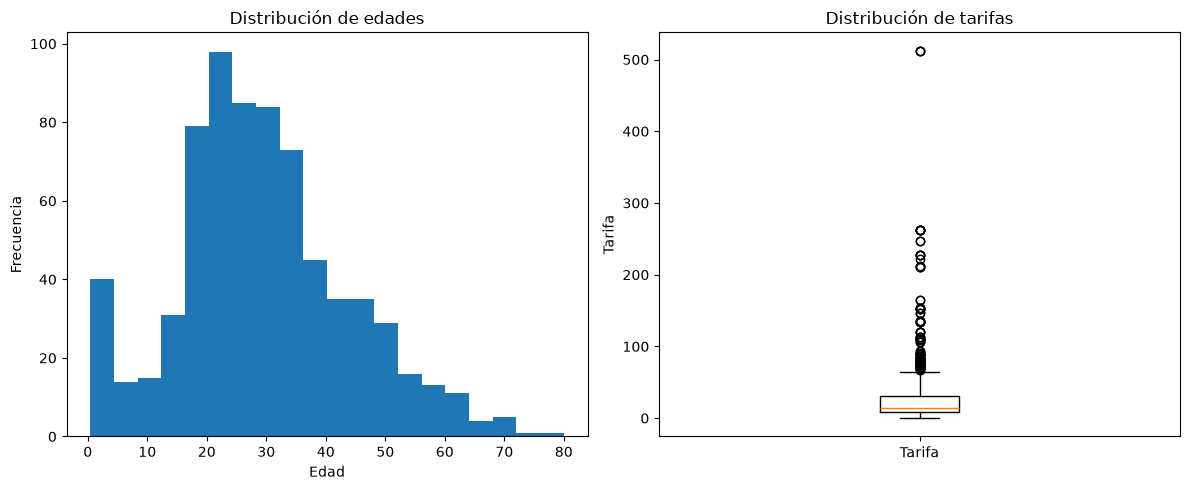

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 5))
 
ejes[0].hist(df['age'].dropna(), bins=20)
ejes[0].set_title('Distribución de edades')
ejes[0].set_xlabel('Edad')
ejes[0].set_ylabel('Frecuencia')
 
ejes[1].boxplot(df['fare'].dropna())
ejes[1].set_title('Distribución de tarifas')
ejes[1].set_ylabel('Tarifa')
ejes[1].set_xticklabels(['Tarifa'])
 
plt.tight_layout()
plt.show()


### Ejercicio 16 — Informe por puerto y exportación

1. Crear una copia de `df` y completar los nulos de `embark_town` con `Sin dato`.
2. Elaborar una tabla por puerto con cantidad de pasajeros, tarifa promedio y porcentaje de supervivencia.
3. Representar el porcentaje de supervivencia por puerto con un gráfico de barras, con eje vertical de 0 a 100.
4. Guardar la tabla en `data/resumen_titanic_por_puerto.csv`, incluyendo el puerto como columna y sin exportar el índice.
5. Volver a leer el archivo y comprobar que conserva las mismas columnas y cantidad de filas.
6. Escribir una conclusión de dos o tres oraciones. Aclarar por qué esta comparación por sí sola no demuestra que el puerto haya causado una diferencia en supervivencia.

**Pista:** usar `.groupby()`, `.agg()`, `.reset_index()` y `.to_csv(index=False)`.

   embark_town  cantidad  tarifa_promedio  porcentaje_supervivencia
0    Cherbourg       168        59.954144                 55.357143
1   Queenstown        77        13.276030                 38.961039
2     Sin dato         2        80.000000                100.000000
3  Southampton       644        27.079812                 33.695652


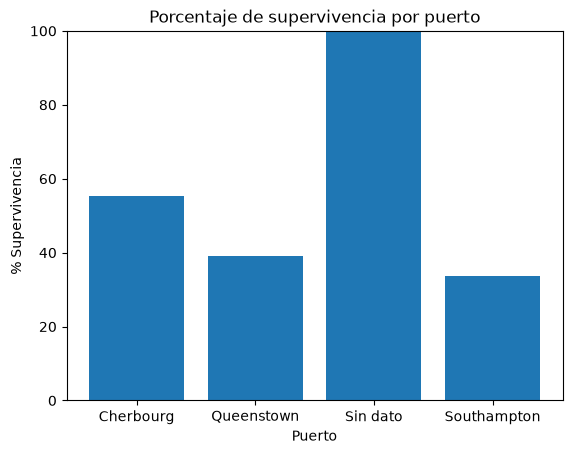

True
True


In [ ]:
df_puertos = df.copy()
df_puertos['embark_town'] = df_puertos['embark_town'].fillna('Sin dato')
 
resumen_puertos = df_puertos.groupby('embark_town').agg(
    cantidad=('survived', 'size'),
    tarifa_promedio=('fare', 'mean'),
    porcentaje_supervivencia=('survived', lambda x: x.mean() * 100)
).reset_index()
 
print(resumen_puertos)
 
plt.bar(resumen_puertos['embark_town'], resumen_puertos['porcentaje_supervivencia'])
plt.ylim(0, 100)
plt.title('Porcentaje de supervivencia por puerto')
plt.xlabel('Puerto')
plt.ylabel('% Supervivencia')
plt.show()
 
resumen_puertos.to_csv('data/resumen_titanic_por_puerto.csv', index=False)
 
verificacion = pd.read_csv('data/resumen_titanic_por_puerto.csv')
print(verificacion.shape == resumen_puertos.shape)
print(list(verificacion.columns) == list(resumen_puertos.columns))


# 7. Introducción a la programación orientada a objetos

La programación orientada a objetos permite representar entidades mediante objetos que reúnen **datos** y **comportamientos**.

- **Clase:** definición o modelo a partir del cual se crean objetos.
- **Objeto o instancia:** elemento concreto creado a partir de una clase.
- **Constructor:** método `__init__`, ejecutado al crear el objeto.
- **Atributos:** datos asociados con cada objeto.
- **Métodos:** funciones definidas dentro de una clase.
- **`self`:** referencia al objeto que está ejecutando el método.

En Python, los atributos suelen crearse dentro de `__init__` mediante asignaciones como `self.nombre = nombre`.

In [ ]:
mediciones_sensor1 = [20, 40]

def calcular_promedio(valores):
    return sum(valores) / len(valores)


print(calcular_promedio(mediciones_sensor1))


In [ ]:
# class define un modelo que agrupa datos (atributos) y operaciones (métodos).
class Sensor:
    # __init__ inicializa cada instancia recién creada; self referencia esa instancia.
    def __init__(self, nombre_del_objeto):
        # Los atributos guardan el estado del objeto y se acceden mediante la notación con punto.
        self.nombre = nombre_del_objeto
        # Esta lista se crea de nuevo para cada instancia: los sensores no comparten mediciones.
        self.mediciones = []

    # Un método es una función definida en la clase que puede operar sobre el objeto.
    def registrar_mediciones(self, valor):
        # append agrega un elemento al final de la lista y modifica el estado del sensor.
        self.mediciones.append(valor)

    def calcular_promedio(self):
        if not self.mediciones:
            # None indica que todavía no hay un promedio disponible y evita dividir por cero.
            return None
        return sum(self.mediciones) / len(self.mediciones)

# Llamar a la clase crea una instancia. Al invocar sus métodos desde sensor,
# Python pasa automáticamente ese objeto como primer argumento, self.
sensor = Sensor("Patio")

sensor.registrar_mediciones(20) # Cuando invoco sensor.registrar_mediciones(20) → regitrar_mediciones(sensor,20)
sensor.registrar_mediciones(2)

print(sensor)
print(sensor.nombre)
print(sensor.mediciones)

print(sensor.calcular_promedio())

sensor_2 = Sensor("Aula")

sensor_2.registrar_mediciones(5)
sensor_2.registrar_mediciones(15)

print(sensor_2.calcular_promedio())

# isinstance comprueba si el objeto pertenece a la clase indicada o a una subclase.
print(isinstance(sensor_2, Sensor))

In [ ]:
# IDENTIDAD

# Dos llamadas a Sensor crean objetos distintos aunque sus nombres tengan el mismo valor.
# == compara aquí las cadenas nombre; is compara la identidad de los objetos.
sensor_3 = Sensor("Cocina")
sensor_4 = Sensor("Cocina")

print(sensor_3.nombre == sensor_4.nombre) # True porque comparten nombre

print(sensor_3 is sensor_4) # False porque estoy comparando identidad y son dos objetos distintos


# ESTADO Y COMPORTAMIENTO

sensor_3.registrar_mediciones(24.5)
print(sensor_3.mediciones) # [24.5]
print(sensor_4.mediciones) # []


# REFERENCIAS: una asignacion no crea otro sensor ni copia sus datos

# Aquí se crea otro objeto. Para compartir una referencia sin crear una instancia nueva
# se escribiría otro_sensor = sensor_3; entonces ambas variables apuntarían al mismo sensor.
otro_sensor = Sensor("Cocina")

print(sensor_3 is otro_sensor)

otro_sensor.registrar_mediciones(5.5)

print(sensor_3.mediciones)

In [ ]:
sensor_5 = Sensor("Aula")

sensor_5.registrar_mediciones(24)

print(sensor_5.nombre)
print(sensor_5.mediciones)

# Al llamar al método desde la clase, la instancia se pasa explícitamente como primer argumento.
Sensor.registrar_mediciones(sensor_5, 26)

print(sensor_5.mediciones)

print(sensor_5.calcular_promedio())

# Sin paréntesis se obtiene un método ligado a sensor_5, sin ejecutarlo.
# metodo() lo ejecuta después y mantiene sensor_5 como receptor.
metodo = sensor_5.calcular_promedio
promedio = metodo()

print(promedio)

### Creación y utilización de un objeto

Al escribir `Agente("Aspiradora")`, Python crea un objeto y ejecuta automáticamente `__init__`. El argumento `"Aspiradora"` se asigna al parámetro `nombre`; `energia` conserva su valor predeterminado.

In [ ]:
# Defino la clase Agente
class Agente:
    def __init__(self, nombre, energia=100):
        self.nombre = nombre
        self.energia = energia
        self.historial = []

    def percibir(self, entorno):
        percepcion = entorno.get("estado")

        if percepcion:
            self.historial.append(f"Percepcion: {percepcion}")

        return percepcion

    def actuar(self, accion):
        if self.energia <= 0:
            return "El agente no tiene energia"

        # -= 10 descuenta diez de la energía actual. Como solo se exige energía positiva,
        # puede quedar negativa si antes había entre 1 y 9 unidades.
        self.energia -= 10
        self.historial.append(f"Accion: {accion}")

        return f"{self.nombre} ejecutó la accion: {accion}"

    def mostrar_estado(self):
        # La tupla devuelve la lista historial original, no una copia de su contenido.
        return self.nombre, self.energia, self.historial
    

In [ ]:
# Defino objeto

agente_aspiradora = Agente("Aspiradora")

# type devuelve la clase a la que pertenece la instancia.
print(type(agente_aspiradora))

print(agente_aspiradora.nombre)

print(agente_aspiradora.energia)

isinstance(agente_aspiradora, Agente)

In [ ]:
entorno = {"estado": "sucio"}

estado_percibido = agente_aspiradora.percibir(entorno)

if estado_percibido == "sucio":
    resultado = agente_aspiradora.actuar("limpiar")

else:
    resultado = agente_aspiradora.actuar("avanzar")

print(resultado)

nombre, energia, historial = agente_aspiradora.mostrar_estado()

print("Nombre:", nombre)

print("Energia:", energia)

print("Historial:", historial)

### Dos objetos de la misma clase

Cada objeto conserva sus propios atributos. Modificar la energía de un agente no modifica la energía del otro.

In [ ]:
# energia=50 pasa un argumento por nombre. Cada agente conserva su propio estado.
agente_1 = Agente("Agente A", energia=50)

agente_2 = Agente("Agente B", energia=80)

agente_1.actuar("explorar")

print(agente_1.nombre, agente_1.energia)
print(agente_2.nombre, agente_2.energia)

### Ejercicio 17

Crear una clase `Sensor` con los atributos `nombre` y `mediciones`. Incorporar métodos para registrar una medición, calcular el promedio y devolver el estado del sensor.

In [ ]:
class Sensor:
    def __init__(self, nombre):
        self.nombre = nombre
        self.mediciones = []

    def registrar_medicion(self, valor):
        self.mediciones.append(valor)

    def calcular_promedio(self):
        if len(self.mediciones) == 0:
            return 0
        return sum(self.mediciones) / len(self.mediciones)

    def mostrar_estado(self):
        return (self.nombre, len(self.mediciones), self.calcular_promedio())


    mediciones = np.array([
    [24.0, 25.0, 24.5],
    [31.0, 32.5, 30.0],
    [27.0, 26.5, 28.0]
])
 
sensores = []
 
for i in range(mediciones.shape[0]):
    sensor = Sensor(f"Sensor {i+1}")
    for valor in mediciones[i]:
        sensor.registrar_medicion(valor)
    sensores.append(sensor)
 
for sensor in sensores:
    nombre, mediciones_registradas, promedio = sensor.mostrar_estado()
    print(f"Nombre: {nombre}, Mediciones: {mediciones_registradas}, Promedio: {promedio:.2f}")


Nombre: Sensor 1, Mediciones: 3, Promedio: 24.50
Nombre: Sensor 2, Mediciones: 3, Promedio: 31.17
Nombre: Sensor 3, Mediciones: 3, Promedio: 27.17


# 8. Ejercicio integrador

A partir de la clase Sensor definida anteriormente, desarrollar un programa que:

- Represente mediante una matriz de NumPy las mediciones realizadas por tres sensores. Cada fila deberá corresponder a un sensor y cada columna, a una medición.
- Recorra las filas de la matriz utilizando range().
- Cree un objeto Sensor por cada fila y registre en él todas sus mediciones.
- Almacene los objetos creados en una lista.
- Recorra la lista de sensores y obtenga, para cada uno, su nombre, su promedio y su estado.

In [ ]:
mediciones = np.array([
    [24.0, 25.0, 24.5],
    [31.0, 32.5, 30.0],
    [27.0, 26.5, 28.0]
])

# Esta lista está preparada para reunir las instancias del ejercicio integrador.
sensores = []

for i in range(mediciones.shape[0]):
    sensor = Sensor(f"Sensor {i+1}")
    for valor in mediciones[i]:
        sensor.registrar_medicion(valor)
    sensores.append(sensor)

for sensor in sensores:
    nombre, mediciones_registradas, promedio = sensor.mostrar_estado()
    print(f"Nombre: {nombre}, Promedio: {promedio:.2f}, Estado: {mediciones_registradas}")


NameError: name 'np' is not defined

## Cierre

En este laboratorio se repasaron estructuras fundamentales de Python y se aplicaron a arrays, tablas y visualizaciones. También se introdujo la programación orientada a objetos mediante clases sencillas que reúnen estado y comportamiento.

### Ideas principales

- Una condición puede evaluar valores *truthy* y *falsy*, pero debe distinguirse `None` de cero cuando el problema lo requiera.
- `range()` genera secuencias enteras y excluye su límite final.
- Una función puede retornar una tupla escribiendo varios valores separados por comas.
- El desempaquetado distribuye los elementos de una secuencia entre variables.
- NumPy permite operar matrices sin recorrer manualmente cada valor.
- Pandas organiza el análisis tabular y Matplotlib permite comunicar los resultados.
- Una clase define atributos y métodos; cada objeto conserva su propio estado.

### Próximamente…

Los conceptos de Python y POO se ampliarán gradualmente a medida que sean necesarios para implementar agentes, estructuras de conocimiento y otros componentes de sistemas de inteligencia artificial.